In [69]:
import importlib
import numpy as np
import os
import polars as pl
import scipy.sparse as sp
import sys
import torch
import torch.nn as nn
from tqdm import tqdm

from datasets import DATA_FOLDER, Dataloader, prepare_interaction_data
from util import CHECKPOINT_FOLDER, get_checkpoint_filepath, load_checkpoint, load_config_from_checkpoint

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.mps.is_available() else torch.device("cpu")

DATASET = "ML-25M"
# checkpoint = "TopKSAE-8192-f634db83.ckpt" #multvae
# checkpoint = "TopKSAE-8192-3c29e9ee.ckpt" #cosine
# checkpoint = "TopKSAE-8192-d6337b64.ckpt"  # l2
checkpoint = "TopKSAE-8192-7420ec46.ckpt"
checkpoint = "TopKSAE-8192-c347146b.ckpt"
checkpoint = "TopKSAE-8192-b457e403.ckpt"

SAE_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/{checkpoint}"


sae_cfg = load_config_from_checkpoint(SAE_CHECKPOINT_PATH)
cf_model_checkpoint_path = f"{CHECKPOINT_FOLDER}/{DATASET}/{sae_cfg['pretrained_model_checkpoint']}"
cf_model_cfg = load_config_from_checkpoint(cf_model_checkpoint_path)

interactions_df, train_csr, val_csr, test_csr, train_users, val_users, test_users, items = prepare_interaction_data(cf_model_cfg)
train_users_to_idxs = {uid: uidx for uidx, uid in enumerate(train_users)}
val_users_to_idxs = {uid: uidx for uidx, uid in enumerate(val_users)}
test_users_to_idxs = {uid: uidx for uidx, uid in enumerate(test_users)}
items_to_idxs = {iid: iidx for iidx, iid in enumerate(items)}

items_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/movies.csv").rename({"movieId": "item_id"}).cast({"item_id": pl.String}).cast({"item_id": pl.Categorical}).collect()
)


cf_model_class = getattr(importlib.import_module(cf_model_cfg["model_module"]), cf_model_cfg["model_class"])
if cf_model_cfg["model_class"] == "ELSA":
    cf_model = cf_model_class(train_csr.shape[1], cf_model_cfg["embedding_dim"]).to(device)
elif cf_model_cfg["model_class"] == "MultVAE":
    cf_model = cf_model_class(
        train_csr.shape[1],
        [int(x) for x in cf_model_cfg["hidden_dims"].split(",") if x.strip()],
        cf_model_cfg["embedding_dim"],
        cf_model_cfg["annealing_beta"],
        cf_model_cfg["annealing_steps"],
    ).to(device)

_, _ = load_checkpoint(cf_model, None, get_checkpoint_filepath(cf_model_cfg), device, None)

sae_model_class = getattr(importlib.import_module(sae_cfg["model_module"]), sae_cfg["model_class"])
sae_extra_params = {k: sae_cfg[k] for k in sae_cfg.keys() if k in ["l1_coef", "k"]}
sae = sae_model_class(cf_model_cfg["embedding_dim"], sae_cfg["embedding_dim"], sae_cfg["reconstruction_loss"], l1_coef=sae_cfg["l1_coef"], k=sae_cfg["k"]).to(
    device
)
_, _ = load_checkpoint(sae, None, get_checkpoint_filepath(sae_cfg), device, None)

Removing users with < 5 interactions...
Dataset info: users=160776, items=40857, interactions=12448242
Train split info: users=128621, items=40857, interactions=10008799
Val split info: users=16078, items=40857, interactions=1208736
Test split info: users=16077, items=40857, interactions=1230707
Loaded checkpoint from checkpoints/ML-25M/MultVAE-1024-2701bf6a.ckpt (after 25 epochs)
Loaded checkpoint from checkpoints/ML-25M/TopKSAE-8192-b457e403.ckpt (after 250 epochs)


In [70]:
sparse_embeddings = []
onehot_items_dataloader = Dataloader(sp.eye(len(items), dtype=np.float32, format="csr"), batch_size=1024, device=device)
with torch.no_grad():
    for onehot_batch in tqdm(onehot_items_dataloader):
        cf_model_embedding = cf_model.encode(onehot_batch)  # Tensor, shape = (batch.shape[0] x elsa_cfg["embedding_dim"])
        if cf_model_cfg["model_class"] != "ELSA":
            cf_model_embedding = cf_model_embedding[0]

        sae_embedding, _, input_mean, input_std = sae.encode(cf_model_embedding)
        sparse_embeddings.append(sp.csr_matrix(sae_embedding.cpu().numpy()))
sparse_embeddings = sp.vstack(sparse_embeddings)

neuron_is_alive = np.asarray(sparse_embeddings.sum(axis=0)).flatten() != 0
living_neurons = np.where(neuron_is_alive)[0]
dead_neuron_count = sparse_embeddings.shape[1] - neuron_is_alive.sum()
print(f"{dead_neuron_count} dead neurons out of {sparse_embeddings.shape[1]} ({dead_neuron_count / sparse_embeddings.shape[1]:.2%})")
print(f"{neuron_is_alive.sum()} alive ones")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:07<00:00,  5.24it/s]

7699 dead neurons out of 8192 (93.98%)
493 alive ones


In [71]:
tag_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/tags.csv")
    .rename({"userId": "user_id", "movieId": "item_id"})
    .cast({"user_id": pl.String, "item_id": pl.String})
    .cast({"user_id": pl.Categorical, "item_id": pl.Categorical})
    .with_columns(pl.col("tag").str.to_lowercase().str.strip_chars().alias("tag"))  # convert to lowercase and strip whitespace
    .filter(pl.col("tag").count().over("tag") >= 100)  # keep only tags assigned at least 100 times
    .filter(pl.col("item_id").is_in(items))  # keep only items with interactions
    .with_columns(pl.col("item_id").replace_strict(items_to_idxs).alias("item_idx"))
    .cast({"tag": pl.Categorical})
    .collect()
)

tag_df

<sys>:0: CategoricalRemappingWarning: Local categoricals have different encodings, expensive re-encoding is done to perform this merge operation. Consider using a StringCache or an Enum type if the categories are known in advance


user_id,item_id,tag,timestamp,item_idx
cat,cat,cat,i64,i64
"""3""","""260""","""classic""",1439472355,43
"""3""","""260""","""sci-fi""",1439472256,43
"""4""","""1732""","""dark comedy""",1573943598,181
"""4""","""1732""","""great dialogue""",1573943604,181
"""4""","""7569""","""so bad it's good""",1573943455,5010
…,…,…,…,…
"""162462""","""260""","""space""",1427470029,43
"""162492""","""260""","""classic sci-fi""",1436468895,43
"""162492""","""260""","""epic""",1436468882,43


In [72]:
tags = tag_df["tag"].unique(maintain_order=True).to_numpy()
tag_item_counts = sp.csr_matrix(
    (
        np.ones(len(tag_df), dtype=np.float32),
        (
            tag_df["tag"].to_physical().to_numpy(),
            tag_df["item_idx"].to_numpy(),
        ),
    ),
    shape=(tag_df["tag"].n_unique(), len(items)),
)

tag_item_counts

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 209685 stored elements and shape (1633, 40857)>

In [73]:
pl.Series(tag_item_counts.data).describe()

statistic,value
str,f64
"""count""",209685.0
"""null_count""",0.0
"""mean""",3.42385
"""std""",8.698483
"""min""",1.0
"""25%""",1.0
"""50%""",1.0
"""75%""",2.0
"""max""",658.0


In [74]:
def compute_tfidf(X):
    """
    Compute TF-IDF for a term-document value matrix.
    Parameters:
    X: np.ndarray (num_terms, num_documents)
    Returns:
    tfidf_matrix: np.ndarray (num_terms, num_documents) - TF-IDF values
    """
    # Compute Term Frequency (TF) - Normalize by column sum
    tf = X / np.sum(X, axis=0, keepdims=True)
    tf[np.isnan(tf)] = 0  # Handle division by zero
    # Compute Document Frequency (DF) - Count nonzero occurrences of each term
    df = np.count_nonzero(X, axis=1)
    # Compute Inverse Document Frequency (IDF) - Log-scaled
    num_documents = X.shape[1]
    idf = np.log((num_documents + 1) / (df + 1)) + 1  # Smoothing
    # Compute TF-IDF
    tfidf_matrix = tf * idf[:, np.newaxis]
    return tfidf_matrix


pti = tag_item_counts.copy()
pti.data /= pti.data.sum()
tag_neuron_activity = pti @ sparse_embeddings

# top_tag_per_neuron = tags[compute_tfidf(tag_neuron_activity.toarray()).argmax(axis=0)]  # term = tag, document = neuron
top_tag_per_neuron = tags[compute_tfidf(tag_neuron_activity.toarray().T).argmax(axis=1)]  # term = neuron, document = tag
top_tag_per_neuron[~neuron_is_alive] = None

# top_neuron_per_tag = compute_tfidf(tag_neuron_activity.toarray().T).argmax(axis=0)  # term = neuron, document = tag
top_neuron_per_tag = compute_tfidf(tag_neuron_activity.toarray()).argmax(axis=1)  # term = tag, document = neuron

print(pl.Series("top_neuron", top_neuron_per_tag).value_counts(sort=True))
print(pl.Series("top_tag", top_tag_per_neuron[neuron_is_alive]).value_counts(sort=True))

shape: (377, 2)
┌────────────┬───────┐
│ top_neuron ┆ count │
│ ---        ┆ ---   │
│ i64        ┆ u32   │
╞════════════╪═══════╡
│ 2342       ┆ 14    │
│ 7239       ┆ 13    │
│ 5071       ┆ 12    │
│ 5703       ┆ 12    │
│ 3637       ┆ 12    │
│ …          ┆ …     │
│ 6692       ┆ 1     │
│ 6899       ┆ 1     │
│ 5515       ┆ 1     │
│ 5145       ┆ 1     │
│ 90         ┆ 1     │
└────────────┴───────┘
shape: (353, 2)
┌───────────────────┬───────┐
│ top_tag           ┆ count │
│ ---               ┆ ---   │
│ str               ┆ u32   │
╞═══════════════════╪═══════╡
│ meg ryan          ┆ 6     │
│ audrey hepburn    ┆ 4     │
│ steve martin      ┆ 4     │
│ thoughtful sci-fi ┆ 3     │
│ marlon brando     ┆ 3     │
│ …                 ┆ …     │
│ zach galifianakis ┆ 1     │
│ paul newman       ┆ 1     │
│ adam sandler      ┆ 1     │
│ kevin spacey      ┆ 1     │
│ kung fu           ┆ 1     │
└───────────────────┴───────┘


/var/folders/0w/2w2_yn9s09vgn2t7w4m1xdh80000gn/T/ipykernel_76350/2475554274.py:10: RuntimeWarning: invalid value encountered in divide
  tf = X / np.sum(X, axis=0, keepdims=True)


In [75]:
pl.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort(by="top neuron").tail(10)

tag,top neuron
str,i64
"""great ending""",8171
"""biblical""",8171
"""kevin spacey""",8171
"""biography""",8191
"""predictable""",8191
"""kung fu""",8191
"""martial arts""",8191
"""netflix""",8191
"""fighting""",8191


In [76]:
import pandas as pd

df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df.tag.str.contains("han")]

,tag,top neuron
298,better than expected,5
929,less than 300 ratings,1298
815,seen more than once,2420
262,tom hanks,3872
1306,hannibal lecter,4396
532,scarlett johansson,5040
943,ethan hawke,5387
872,jackie chan,5451
90,orphans,5850
34,hans zimmer,6443


In [77]:
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df["top neuron"] == 2491]

,tag,top neuron


In [78]:
top_tag_per_neuron[2491]

In [79]:
import pandas as pd

df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.iloc[400:450]

,tag,top neuron
969,sandra bullock,2016
163,hospital,2016
1536,brother,2016
756,feel good movie,2016
651,independent film,2022
1501,parent child relationship,2022
800,r,2022
458,bd-r,2022
1463,florida,2022
749,dysfunctional family,2022


In [80]:
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df.tag.str.contains("hans")]

,tag,top neuron
532,scarlett johansson,5040
90,orphans,5850
34,hans zimmer,6443


In [81]:
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df["top neuron"] == 7599]

,tag,top neuron


In [82]:
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df["top neuron"] == 2491]

,tag,top neuron


In [83]:
tag_df.filter(pl.col("tag") == "hannibal lecter")["item_id"].unique()

item_id
cat
"""593"""
"""4148"""
"""4210"""
"""5630"""
"""50804"""


In [84]:
list(tag_df.filter(pl.col("item_id") == "260")["tag"].unique())

['classic',
 'sci-fi',
 'horror',
 'adventure',
 'anime',
 'fantasy',
 'music',
 'aliens',
 'franchise',
 'science fiction',
 'space',
 'space travel',
 'boring',
 'love story',
 'philosophy',
 'thought-provoking',
 'drama',
 'war',
 'western',
 'atmospheric',
 'incest',
 'friendship',
 'usa',
 'love',
 'oscar winner',
 'robots',
 'star wars',
 'funny',
 'action',
 'george lucas',
 'romance',
 'family',
 'mystery',
 'interesting',
 'thriller',
 'dialogue',
 'touching',
 'gay',
 'soundtrack',
 'politics',
 'humorous',
 'nostalgic',
 'alternate reality',
 'children',
 'story',
 'original plot',
 'original',
 'espionage',
 'future',
 'good acting',
 'slow',
 'acting',
 'oscar nominee: best picture',
 'space adventure',
 'witty',
 'smart',
 'cult film',
 'dark',
 'inspiring',
 'magic',
 'innovative',
 'special effects',
 'cult classic',
 'great soundtrack',
 'stylized',
 'comedy',
 'awesome',
 'classic sci-fi',
 'good vs evil',
 'futuristic',
 'coming of age',
 'rebellion',
 'quotable',
 '

In [85]:
top_tag_per_neuron[6040]

In [86]:
normalized_tag_neuron_activity = compute_tfidf(tag_neuron_activity.toarray().T)  # term = neuron, document = tag
normalized_tag_neuron_activity.shape

(8192, 1633)

In [87]:
mean_neuron_activity = normalized_tag_neuron_activity.sum(axis=0)
mean_neuron_activity.shape

(1633,)

In [88]:
epsilon = 1e-9
import pandas as pd
from scipy.stats import entropy

neuron_entropy = []
neuron_kl_div = []
neuron_top_tags = []
neuron_top_movies = []
valid_neurons = []

for n in range(normalized_tag_neuron_activity.shape[0]):
    neron_tag_activation = normalized_tag_neuron_activity[n, :]
    if neron_tag_activation.sum() > 0:  # living neuron
        n_entropy = entropy(neron_tag_activation)

        neron_tag_activation = neron_tag_activation.copy() + epsilon
        n_kl_div = entropy(mean_neuron_activity, neron_tag_activation)
        # n_kl_div = entropy(neron_tag_activation,mean_neuron_activity)

        valid_neurons.append(n)
        neuron_entropy.append(n_entropy)
        neuron_kl_div.append(n_kl_div)


res = pd.DataFrame({"id": valid_neurons, "entropy": neuron_entropy, "KL_div": neuron_kl_div})
res

,id,entropy,KL_div
0,5,4.745201,11.080589
1,38,3.170506,11.501908
2,59,3.830160,12.121336
3,90,7.244140,0.306329
4,101,4.105300,11.502266
...,...,...,...
488,8089,4.204920,11.769715
489,8161,3.512637,11.594949
490,8167,4.936119,9.675981
491,8171,3.627357,11.946302


In [89]:
res["norm_entropy_diff"] = (entropy(mean_neuron_activity) - res.entropy) / entropy(mean_neuron_activity)

In [90]:
chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
res.to_csv(f"results/res_neuron_tag_{chckpt_name}.csv")

In [91]:
entropy(mean_neuron_activity)

np.float64(7.397122141298755)

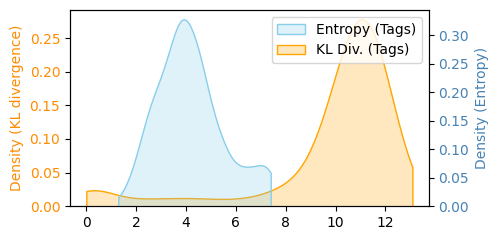

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

min_entropy = res["entropy"].min()
max_entropy = res["entropy"].max()

min_kldiv = res["KL_div"].min()
max_kldiv = res["KL_div"].max()

# Initialize the plot
fig, ax2 = plt.subplots(figsize=(5, 2.5))

sns.kdeplot(res["KL_div"], ax=ax2, label="KL Div. (Tags)", fill=True, color="orange", linestyle="-", clip=(min_kldiv, max_kldiv))

ax2.set_ylabel("Density (KL divergence)", color="#FF8C00")
ax2.tick_params(axis="y", labelcolor="#FF8C00")

# Create a second y-axis for KL_div
ax1 = ax2.twinx()


# Plot the KDE for entropy on the first y-axis
sns.kdeplot(res["entropy"], ax=ax1, label="Entropy (Tags)", fill=True, color="skyblue", linestyle="-", clip=(min_entropy, max_entropy))

ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("Density (Entropy)", color="#4682B4")
ax1.tick_params(axis="y", labelcolor="#4682B4")


# Add a title and legend
# plt.title("KDE of Entropy and KL Divergence with Dual Axes")
handles, labels = ax1.get_legend_handles_labels()  # Get handles and labels from ax1
handles2, labels2 = ax2.get_legend_handles_labels()  # Get handles and labels from ax2

# Combine the handles and labels from both axes
handles.extend(handles2)
labels.extend(labels2)

# Show the legend
plt.legend(handles=handles, labels=labels, loc="upper right")
fig.tight_layout()

# ax1.set_xlim(-0.5, 24)
plt.savefig("rq2_neuron_tag_tfidf.pdf")

In [93]:
normalized_tag_neuron_activity = compute_tfidf(tag_neuron_activity.toarray()).T  # term = tag, document = neuron
normalized_tag_neuron_activity.shape

/var/folders/0w/2w2_yn9s09vgn2t7w4m1xdh80000gn/T/ipykernel_76350/2475554274.py:10: RuntimeWarning: invalid value encountered in divide
  tf = X / np.sum(X, axis=0, keepdims=True)


(8192, 1633)

In [94]:
mean_tag_activity = normalized_tag_neuron_activity.sum(axis=1)
mean_tag_activity.shape

(8192,)

In [95]:
import pandas as pd
from scipy.stats import entropy

neuron_entropy = []
neuron_kl_div = []
neuron_top_tags = []
neuron_top_movies = []
valid_tags = []

for t in range(normalized_tag_neuron_activity.shape[1]):
    neron_tag_activation = normalized_tag_neuron_activity[:, t]
    if neron_tag_activation.sum() > 0:  # living neuron
        n_entropy = entropy(neron_tag_activation)

        neron_tag_activation = neron_tag_activation.copy() + epsilon
        n_kl_div = entropy(mean_tag_activity, neron_tag_activation)
        # n_kl_div = entropy(neron_tag_activation,mean_tag_activity)

        valid_tags.append(t)
        neuron_entropy.append(n_entropy)
        neuron_kl_div.append(n_kl_div)


res = pd.DataFrame({"id": valid_tags, "tag": tags[valid_tags], "entropy": neuron_entropy, "KL_div": neuron_kl_div})
res

,id,tag,entropy,KL_div
0,0,classic,4.815731,8.684299
1,1,sci-fi,4.705235,10.428476
2,2,dark comedy,4.425786,10.696908
3,3,great dialogue,3.357024,12.021523
4,4,so bad it's good,3.521545,11.473150
...,...,...,...,...
1628,1628,02/11,3.542605,10.609592
1629,1629,03/11,3.571867,10.530788
1630,1630,05/11,3.595347,10.503792
1631,1631,06/11,3.228958,10.853236


In [96]:
res["norm_entropy_diff"] = (entropy(mean_tag_activity) - res.entropy) / entropy(mean_tag_activity)

In [97]:
chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
res.to_csv(f"results/res_tag_neuron_{chckpt_name}.csv")

In [98]:
entropy(mean_tag_activity)

np.float64(6.200324219189543)

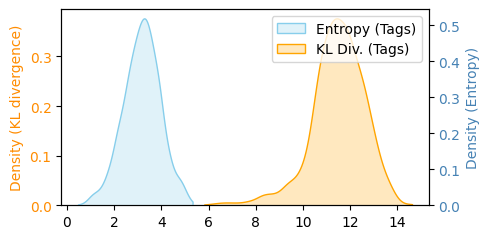

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

min_entropy = res["entropy"].min()
max_entropy = res["entropy"].max()

min_kldiv = res["KL_div"].min()
max_kldiv = res["KL_div"].max()

# Initialize the plot
fig, ax2 = plt.subplots(figsize=(5, 2.5))

sns.kdeplot(res["KL_div"], ax=ax2, label="KL Div. (Tags)", fill=True, color="orange", linestyle="-", clip=(min_kldiv, max_kldiv))

ax2.set_ylabel("Density (KL divergence)", color="#FF8C00")
ax2.tick_params(axis="y", labelcolor="#FF8C00")

# Create a second y-axis for KL_div
ax1 = ax2.twinx()


# Plot the KDE for entropy on the first y-axis
sns.kdeplot(res["entropy"], ax=ax1, label="Entropy (Tags)", fill=True, color="skyblue", linestyle="-", clip=(min_entropy, max_entropy))

ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("Density (Entropy)", color="#4682B4")
ax1.tick_params(axis="y", labelcolor="#4682B4")


# Add a title and legend
# plt.title("KDE of Entropy and KL Divergence with Dual Axes")
handles, labels = ax1.get_legend_handles_labels()  # Get handles and labels from ax1
handles2, labels2 = ax2.get_legend_handles_labels()  # Get handles and labels from ax2

# Combine the handles and labels from both axes
handles.extend(handles2)
labels.extend(labels2)

# Show the legend
plt.legend(handles=handles, labels=labels, loc="upper right")
fig.tight_layout()

# ax1.set_xlim(-0.5, 24)
plt.savefig("rq2_tag_neuron_tfidf.pdf")

In [100]:
res.sort_values("entropy")

,id,tag,entropy,KL_div,norm_entropy_diff
526,526,finnish,0.465988,13.586977,0.924845
276,276,michael moore,0.707310,13.599323,0.885924
594,594,thoughtful sci-fi,0.826517,12.955908,0.866698
1179,1179,stand-up comedy,0.847209,13.714327,0.863361
246,246,cryptography,0.918613,12.989303,0.851844
...,...,...,...,...,...
91,91,funny,5.165460,6.769872,0.166905
61,61,based on a book,5.178091,6.134673,0.164868
1598,1598,bd-video,5.187721,6.458394,0.163315
54,54,drama,5.206783,6.292281,0.160240


In [101]:
res.sort_values("KL_div")

,id,tag,entropy,KL_div,norm_entropy_diff
41,41,boring,5.321054,5.817145,0.141810
61,61,based on a book,5.178091,6.134673,0.164868
54,54,drama,5.206783,6.292281,0.160240
1598,1598,bd-video,5.187721,6.458394,0.163315
1605,1605,dvd-video,5.046976,6.479432,0.186014
...,...,...,...,...,...
1376,1376,peter sellers,0.941329,13.937564,0.848181
1567,1567,eddie murphy,1.505411,13.965482,0.757205
1473,1473,marx brothers,0.985461,14.245088,0.841063
338,338,jim carrey,2.379663,14.524934,0.616203
